In [48]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 设置代理（端口号通常为 7890 或 10809，请按实际工具配置修改）
proxy = 'http://127.0.0.1:7897'
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

# 2. 获取苹果股票数据
data = yf.download('AAPL', start='2025-01-01', end='2025-12-31')
print(data)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-01-02  242.301910  247.518580  240.284799  247.349646  55740700
2025-01-03  241.815033  242.629819  240.354364  241.815033  40244100
2025-01-06  243.444611  245.759820  241.656035  242.758989  45045600
2025-01-07  240.672348  243.991141  239.817807  241.437449  40856000
2025-01-08  241.159210  242.162808  238.526040  240.384163  37628900
...                ...         ...         ...         ...       ...
2025-12-23  271.854919  271.994674  269.060124  270.337749  29642000
2025-12-24  273.302216  274.919206  271.695216  271.834940  17910600
2025-12-26  272.893005  274.859353  272.353998  273.651606  21521800
2025-12-29  273.252350  273.851213  271.844961  272.184327  23715200
2025-12-30  272.573547  273.571693  271.775043  272.304059  22139600

[249 rows x 5 columns]


当前的列索引：
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

列索引层级：
2

展平后的列名：
Index(['Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL'], dtype='object')

找到的列：
Open: Open_AAPL
High: High_AAPL
Low: Low_AAPL
Close: Close_AAPL
Volume: Volume_AAPL


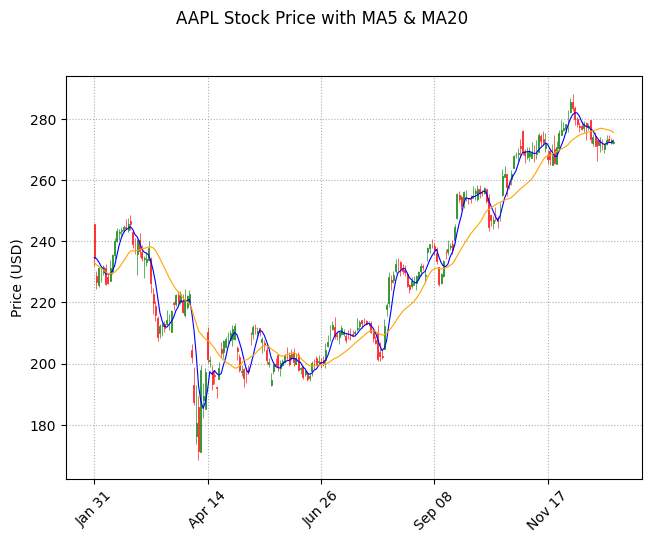

In [50]:
# 首先查看当前的列索引结构
print("当前的列索引：")
print(data.columns)
print("\n列索引层级：")
print(data.columns.nlevels)

# 如果是多层索引，先展平列名
if data.columns.nlevels > 1:
    # 方法1：将多层索引合并为一层
    data.columns = ['_'.join(col).strip() for col in data.columns.values]

    # 或者方法2：直接删除最外层（根据你的原代码）
    # data.columns = data.columns.droplevel(0)  # 删除第一层

    print("\n展平后的列名：")
    print(data.columns)

# 现在将需要的列提取出来
# 找出包含Open、High、Low、Close、Volume的列
open_col = [col for col in data.columns if 'Open' in col][0]
high_col = [col for col in data.columns if 'High' in col][0]
low_col = [col for col in data.columns if 'Low' in col][0]
close_col = [col for col in data.columns if 'Close' in col][0]
volume_col = [col for col in data.columns if 'Volume' in col][0]

print(f"\n找到的列：")
print(f"Open: {open_col}")
print(f"High: {high_col}")
print(f"Low: {low_col}")
print(f"Close: {close_col}")
print(f"Volume: {volume_col}")

# 重命名列为标准名称
data.rename(columns={
    open_col: 'Open',
    high_col: 'High',
    low_col: 'Low',
    close_col: 'Close',
    volume_col: 'Volume'
}, inplace=True)

# 确保数据类型正确
price_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in price_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# 删除任何转换失败产生的NaN值
data = data.dropna().copy()

# 计算双均线
data['MA5'] = data['Close'].rolling(window=5).mean()
data['MA20'] = data['Close'].rolling(window=20).mean()

# 删除均线计算产生的NaN值
data = data.dropna().copy()

# 生成交易信号
data['Signal'] = 0
data.loc[data['MA5'] > data['MA20'], 'Signal'] = 1
data['Position'] = data['Signal'].diff()

# 找出具体的买卖点
buy_signals = data[data['Position'] == 1]
sell_signals = data[data['Position'] == -1]

# 计算收益率
data['Returns'] = data['Close'].pct_change()

# 创建K线图
import mplfinance as mpf

# 准备K线图需要的数据
data_k = data[['Open', 'High', 'Low', 'Close', 'Volume']]

# 绘制K线图和双均线
mc = mpf.make_marketcolors(
    up='green',
    down='red',
    edge='inherit',
    wick='inherit',
    volume='inherit'
)

s = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', y_on_right=False)

# 添加均线
apds = [
    mpf.make_addplot(data['MA5'], color='blue', width=0.8),
    mpf.make_addplot(data['MA20'], color='orange', width=0.8)
]

# 绘制图表
mpf.plot(
    data_k,
    type='candle',
    style=s,
    addplot=apds,
    title='AAPL Stock Price with MA5 & MA20',
    ylabel='Price (USD)',
    volume=False
)

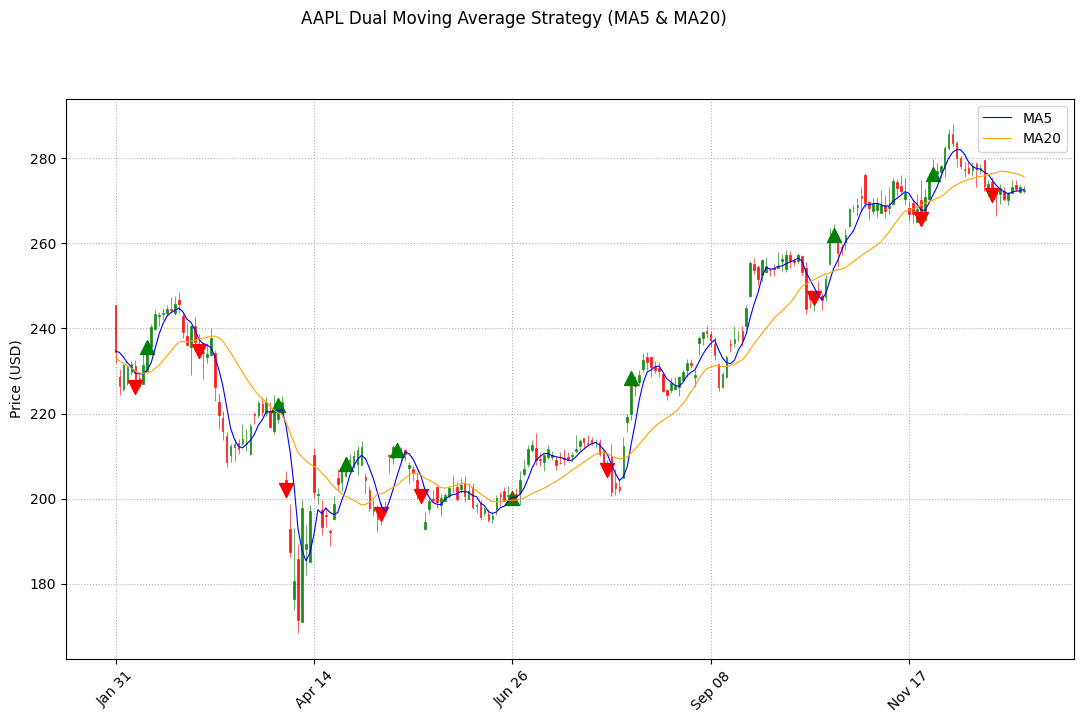

In [51]:
# 修改标注买卖点的部分
# 创建两个全长的Series，只在买卖点位置有值，其他地方为NaN
buy_markers = pd.Series(index=data.index, dtype=float)
sell_markers = pd.Series(index=data.index, dtype=float)

# 只在买卖点位置赋值
buy_markers[buy_signals.index] = buy_signals['Close']
sell_markers[sell_signals.index] = sell_signals['Close']

# 添加均线和标记
apds = [
    mpf.make_addplot(data['MA5'], color='blue', width=0.8, label='MA5'),
    mpf.make_addplot(data['MA20'], color='orange', width=0.8, label='MA20'),
    # 买入点（绿色向上箭头）- 使用全长Series
    mpf.make_addplot(buy_markers, type='scatter', markersize=100, marker='^', color='green'),
    # 卖出点（红色向下箭头）- 使用全长Series
    mpf.make_addplot(sell_markers, type='scatter', markersize=100, marker='v', color='red')
]

# 其余代码保持不变
mc = mpf.make_marketcolors(up='green', down='red', edge='inherit', wick='inherit', volume='inherit')
s = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', y_on_right=False)

mpf.plot(data[['Open', 'High', 'Low', 'Close', 'Volume']],
         type='candle',
         style=s,
         addplot=apds,
         title='AAPL Dual Moving Average Strategy (MA5 & MA20)',
         ylabel='Price (USD)',
         volume=False,
         figsize=(14, 8))


双均线策略表现报告（修正版）
总交易次数: 8
胜率: 0.00%
策略总收益率: -12.98%
买入持有收益率: 16.24%
超额收益: -29.21%
年化收益率: -14.13%
最大回撤: -22.21%


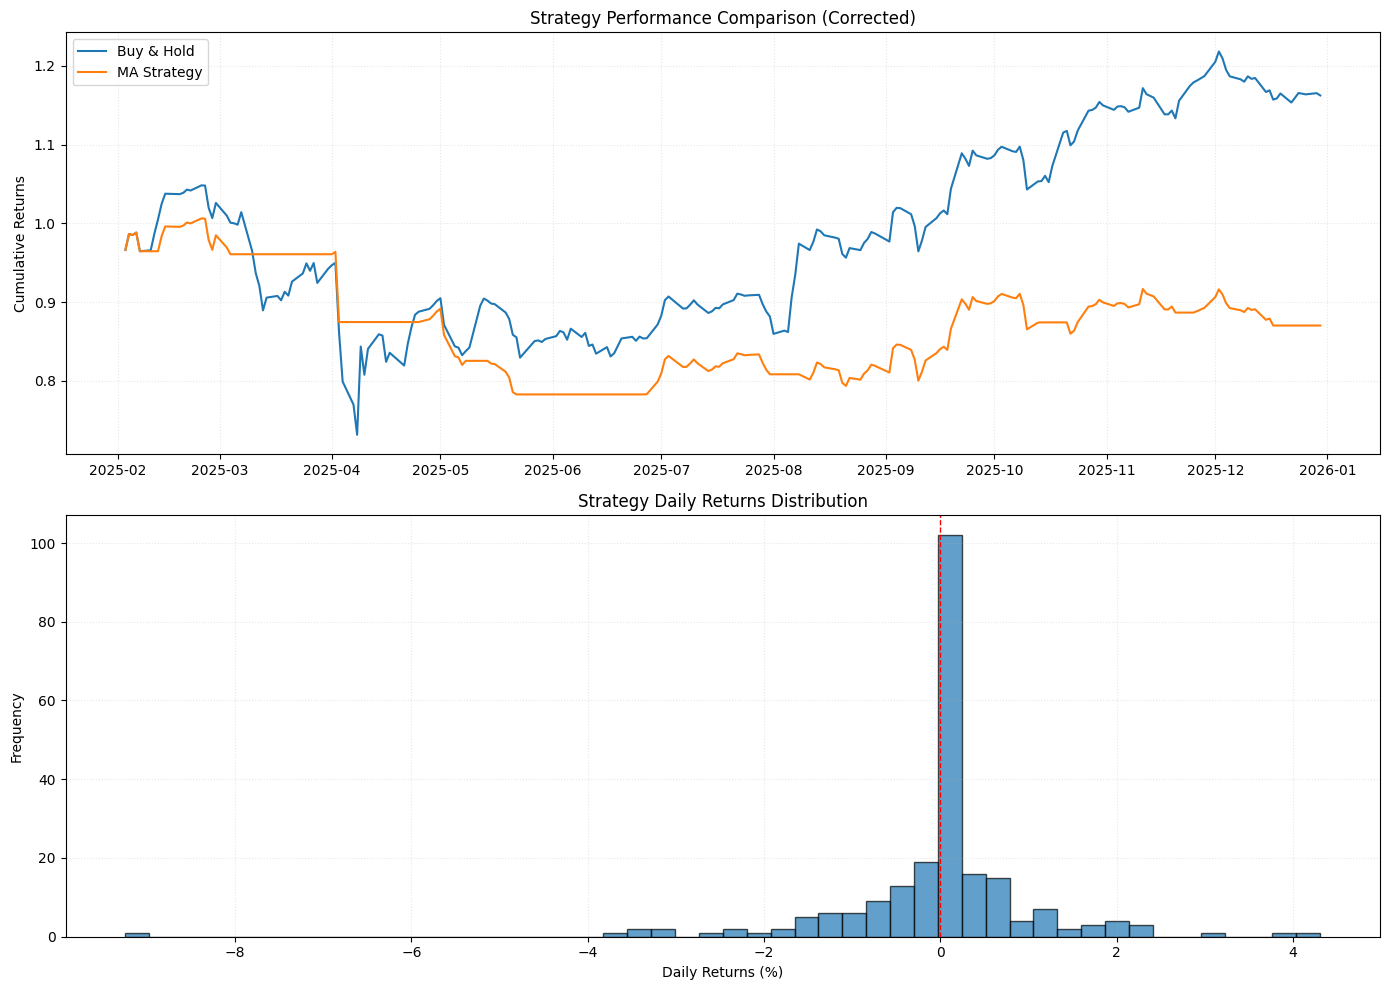

In [53]:
# 重新计算策略收益率（修正版）
# 方法：当MA5 > MA20时持仓，否则空仓
data['Position_Holdings'] = (data['MA5'] > data['MA20']).astype(int)

# 策略每日收益率 = 前一天持仓状态 * 当日市场收益率
data['Strategy_Returns'] = data['Position_Holdings'].shift(1) * data['Returns']

# 计算买卖点（用于统计交易次数）
data['Signal_Change'] = data['Position_Holdings'].diff()
buy_signals_correct = data[data['Signal_Change'] == 1]   # 从0变1，买入
sell_signals_correct = data[data['Signal_Change'] == -1]  # 从1变0，卖出

# 计算累计收益率
data['Cumulative_Market'] = (1 + data['Returns']).cumprod()
data['Cumulative_Strategy'] = (1 + data['Strategy_Returns']).cumprod()

# 计算策略表现指标
total_days = len(data)
trade_count = len(buy_signals_correct)  # 交易次数 = 买入次数

# 计算每笔交易的盈亏
trade_returns = []
for i in range(len(buy_signals_correct)):
    buy_date = buy_signals_correct.index[i]
    # 找到对应的卖出日期
    if i < len(sell_signals_correct):
        sell_date = sell_signals_correct.index[i]
        trade_return = (data.loc[sell_date, 'Cumulative_Strategy'] /
                       data.loc[buy_date, 'Cumulative_Strategy'] - 1)
        trade_returns.append(trade_return)

# 胜率
win_trades = sum(1 for r in trade_returns if r > 0)
win_rate = (win_trades / len(trade_returns) * 100) if trade_returns else 0

# 最大回撤
cumulative = data['Cumulative_Strategy']
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max
max_drawdown = drawdown.min()

# 年化收益率（假设252个交易日）
years = total_days / 252
annual_return = (data['Cumulative_Strategy'].iloc[-1] ** (1/years) - 1) if years > 0 else 0

# 输出策略表现
print("\n" + "="*50)
print("双均线策略表现报告（修正版）")
print("="*50)
print(f"总交易次数: {trade_count}")
print(f"胜率: {win_rate:.2f}%")
print(f"策略总收益率: {(data['Cumulative_Strategy'].iloc[-1]-1)*100:.2f}%")
print(f"买入持有收益率: {(data['Cumulative_Market'].iloc[-1]-1)*100:.2f}%")
print(f"超额收益: {(data['Cumulative_Strategy'].iloc[-1] - data['Cumulative_Market'].iloc[-1])*100:.2f}%")
print(f"年化收益率: {annual_return*100:.2f}%")
print(f"最大回撤: {max_drawdown*100:.2f}%")

# 绘制收益曲线对比图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(data.index, data['Cumulative_Market'], label='Buy & Hold', linewidth=1.5)
ax1.plot(data.index, data['Cumulative_Strategy'], label='MA Strategy', linewidth=1.5)
ax1.set_title('Strategy Performance Comparison (Corrected)', fontsize=12)
ax1.set_ylabel('Cumulative Returns', fontsize=10)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.hist(data['Strategy_Returns'].dropna() * 100, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax2.set_title('Strategy Daily Returns Distribution', fontsize=12)
ax2.set_xlabel('Daily Returns (%)', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()